In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/pca_data07.csv")

df.head()

,Unnamed: 0,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,...,region,customer_segment,estimated_annual_spend,purchase_value_index,engagement_score,discount_dependency,customer_value_score,Cluster,DBSCAN_Cluster,Hierarchical_Cluster
0,0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,...,Semi-Urban,Occasional,1457.166781,54.610162,63.173486,0.117256,99.241287,1,0,1
1,1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,...,Urban,Occasional,6870.632088,435.465225,292.663757,0.261647,1818.742563,3,8,2
2,2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,...,Rural,Occasional,3199.126755,194.797008,421.069457,0.284785,723.313990,0,1,3
3,3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,...,Rural,High_Value,8297.428299,585.951173,632.696615,0.104832,3840.310600,3,-1,2
4,4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,...,Semi-Urban,Occasional,9991.977507,478.096258,67.586178,0.409204,1122.755920,2,0,3


In [2]:
import pickle

with open("../data/processed_variables.pkl", "rb") as f:
    data = pickle.load(f)

df = data["df"]
features = data["features"]
x_scaled = data["x_scaled"]
x_scaled_df = data["x_scaled_df"]
scaler = data["scaler"]
final_kmeans = ["final_kmeans"]
dbscan_results =["dbscan_results"]
comparison = ["comparison"]

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x_scaled)

In [4]:
import pandas as pd
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"].values

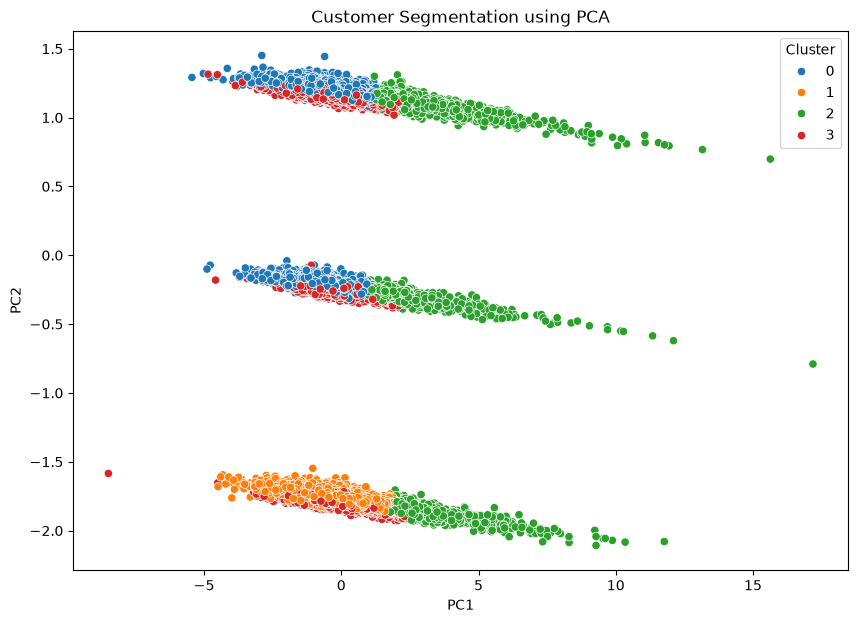

In [5]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10"
)

plt.title("Customer Segmentation using PCA")
plt.show()

In [6]:
pca.explained_variance_ratio_

array([0.12851252, 0.11828686])

In [7]:
pca.explained_variance_ratio_.sum()

np.float64(0.24679937688919196)

In [8]:
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,...,region,customer_segment,estimated_annual_spend,purchase_value_index,engagement_score,discount_dependency,customer_value_score,Cluster,DBSCAN_Cluster,Hierarchical_Cluster
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,...,Semi-Urban,Occasional,1457.166781,54.610162,63.173486,0.117256,99.241287,1,0,1
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,...,Urban,Occasional,6870.632088,435.465225,292.663757,0.261647,1818.742563,3,8,2
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,...,Rural,Occasional,3199.126755,194.797008,421.069457,0.284785,723.313990,0,1,3
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,...,Rural,High_Value,8297.428299,585.951173,632.696615,0.104832,3840.310600,3,-1,2
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,...,Semi-Urban,Occasional,9991.977507,478.096258,67.586178,0.409204,1122.755920,2,0,3


In [9]:
cluster_profile = df.groupby("Cluster").agg({
    "age": "mean",
    "annual_income": "mean",
    "months_active": "mean",
    "avg_monthly_spend": "mean",
    "purchase_frequency": "mean",
    "avg_order_value": "mean",
    "discount_usage_rate": "mean",
    "return_rate": "mean",
    "browsing_time_minutes": "mean",
    "support_interactions": "mean",
    "customer_id": "count"
})

In [10]:
cluster_profile = cluster_profile.rename(
    columns={"customer_id": "customer_count"}
)

In [11]:
cluster_profile

,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,customer_count
Cluster,,,,,,,,,,,
0,44.178094,44639.303951,36.549666,284.804221,5.329081,54.672339,0.283412,0.148960,62.016630,1.504370,23336
1,44.091643,44308.306481,36.189652,303.668255,5.136793,62.222367,0.286236,0.150290,61.480163,1.498841,11152
2,43.601192,44759.242895,36.209341,645.422756,2.604725,213.707652,0.288004,0.146145,62.058527,1.463362,6038
3,43.722504,44442.231974,36.809373,309.789908,5.084419,64.248619,0.282154,0.149211,61.379586,1.485481,9474


In [12]:
segment_mapping = {
    0: "Premium Loyal Customers",
    1: "Budget-Conscious Customers",
    2: "At-Risk Customers",
    3: "High-Engagement Customers"
}

df["Segment_Name"] = df["Cluster"].map(segment_mapping)

In [13]:
pd.crosstab(
    df["customer_segment"],
    df["Segment_Name"]
)

Segment_Name,At-Risk Customers,Budget-Conscious Customers,High-Engagement Customers,Premium Loyal Customers
customer_segment,,,,
High_Value,517,1122,1021,2613
Loyal,74,2233,1891,4965
Occasional,4922,4788,3910,8489
Regular,525,3009,2652,7269


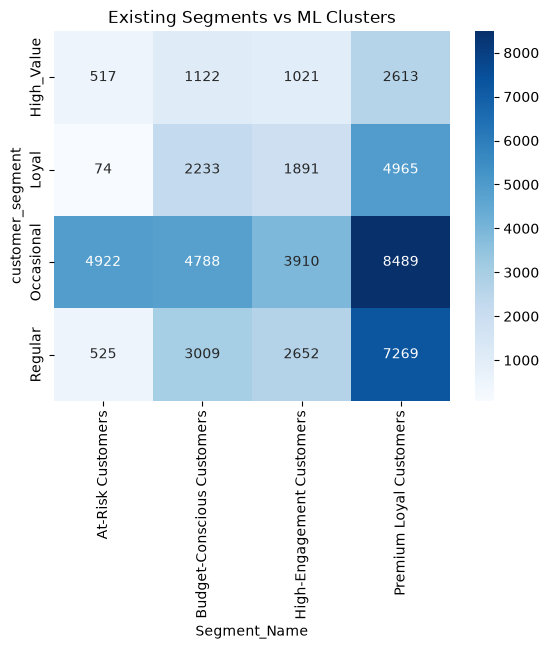

In [14]:
comparison_table = pd.crosstab(
    df["customer_segment"],
    df["Segment_Name"]
)

sns.heatmap(
    comparison_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Existing Segments vs ML Clusters")
plt.show()

In [15]:
business_insights = pd.DataFrame({
    "Segment": [
        "Premium Loyal Customers",
        "Budget-Conscious Customers",
        "At-Risk Customers",
        "Return-Prone Customers"
    ],
    "Characteristics": [
        "High spending and frequent purchases",
        "High discount dependency",
        "Low engagement and spending",
        "High return and support rates"
    ],
    "Recommendation": [
        "Loyalty rewards and premium offers",
        "Discount bundles and personalized coupons",
        "Re-engagement campaigns",
        "Improve product experience and support"
    ]
})

In [16]:
df.to_csv(
    "../data/processed/customer_intelligence.csv",
    index=False
)

In [17]:
cluster_profile.to_csv(
    "../data/processed/cluster_profiles.csv"
)

In [18]:
pca_df.to_csv(
    "../data/processed/pca_data.csv",
    index=False
)